<a href="https://colab.research.google.com/github/24JE0305/-Students-Performance-predictor/blob/main/student_success.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## importing Library and Data

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,accuracy_score,classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV

In [146]:
df = pd.read_csv('Student_performance_data _.csv')

In [147]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## EDA

In [148]:

df.shape

(2392, 15)

In [149]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


**Student ID** is useless so it is better to drop.

In [150]:
df.drop('StudentID',axis = 1,inplace=True)
df.drop('GPA',axis = 1,inplace = True)

In [151]:
df.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,4.0


In [152]:
df.isnull().sum().sum()

np.int64(0)

In [153]:
df.duplicated().sum()

np.int64(0)

In [154]:
df['GradeClass'].unique()

array([2., 1., 4., 3., 0.])

In [155]:
df['GradeClass'] = df['GradeClass'].astype(int)

In [156]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering', 'GradeClass'],
      dtype='object')

In [157]:
num_cols = ['Age', 'StudyTimeWeekly','Absences']
cat_cols = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports','Music', 'Volunteering', 'GradeClass']

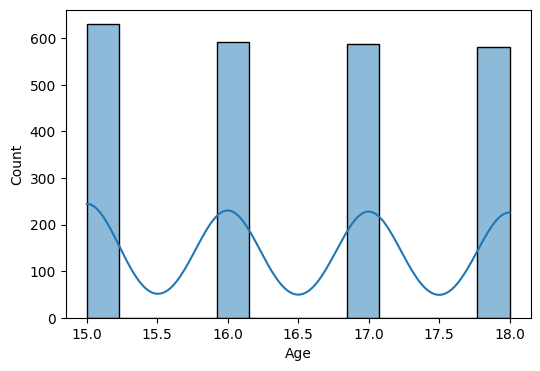

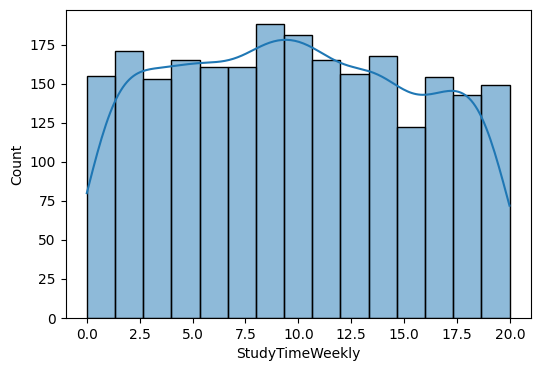

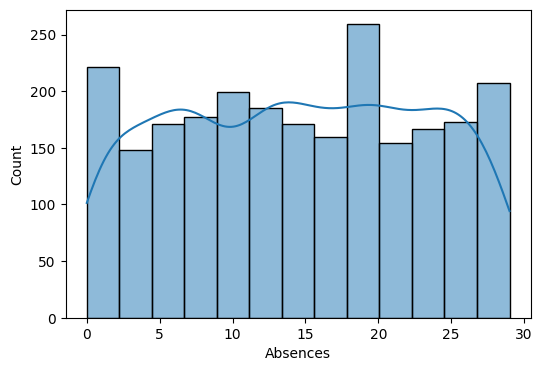

In [158]:
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde =True)

In [159]:
df['Age'].unique()

array([17, 18, 15, 16])

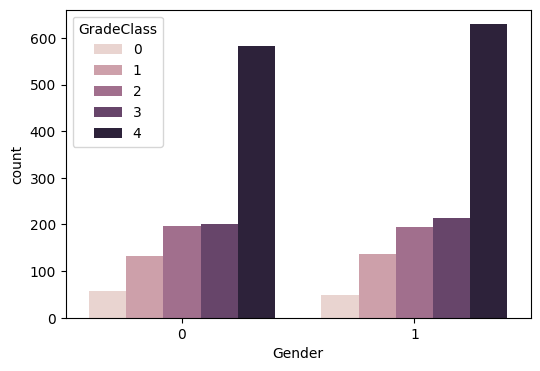

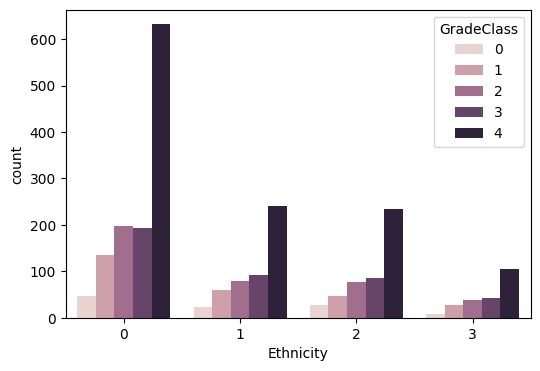

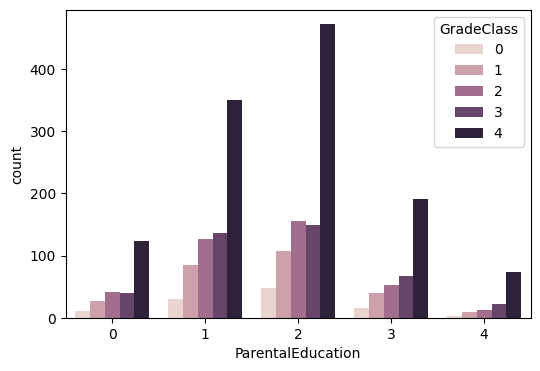

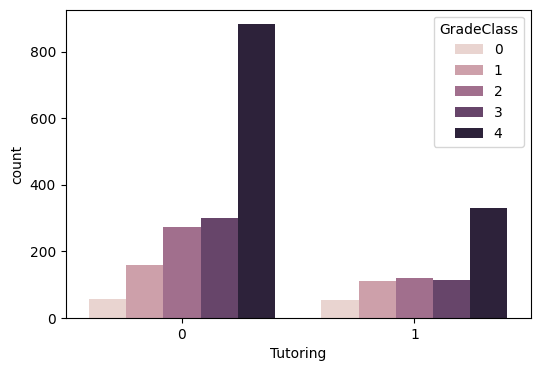

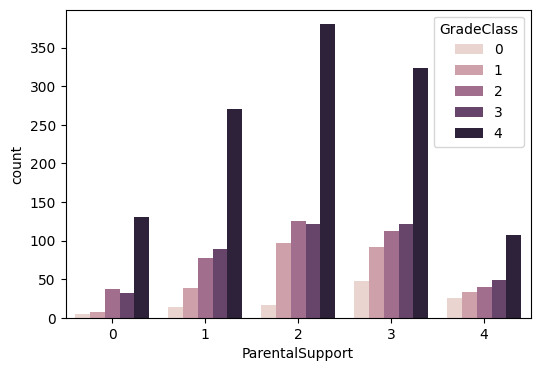

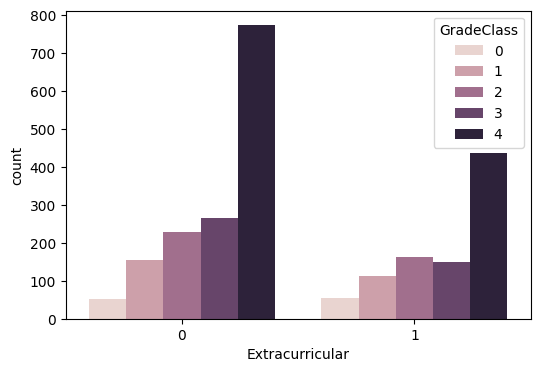

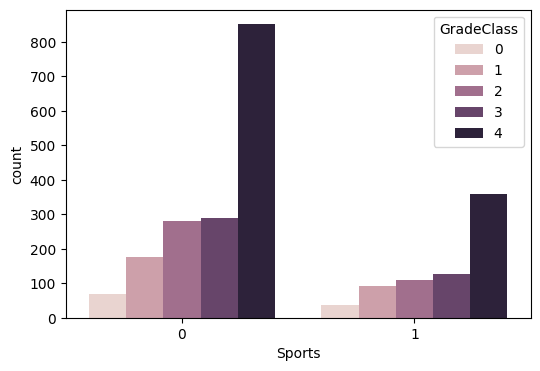

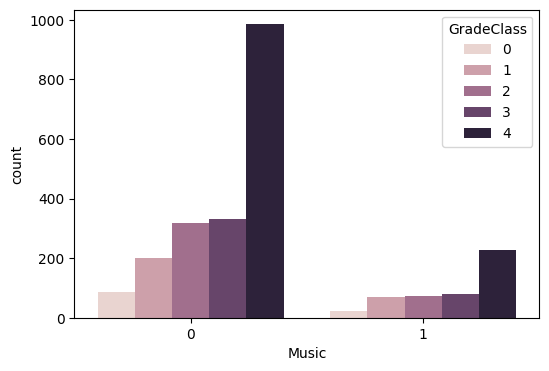

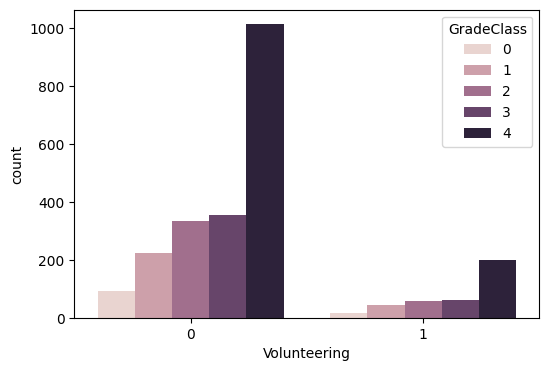

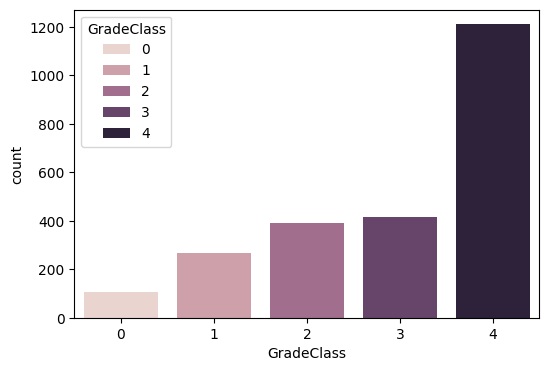

In [160]:
for col in cat_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(data=df, x=col,hue = 'GradeClass')

In [161]:
for col in cat_cols:
  print(df[col].value_counts())
  print("")

Gender
1    1222
0    1170
Name: count, dtype: int64

Ethnicity
0    1207
1     493
2     470
3     222
Name: count, dtype: int64

ParentalEducation
2    934
1    728
3    367
0    243
4    120
Name: count, dtype: int64

Tutoring
0    1671
1     721
Name: count, dtype: int64

ParentalSupport
2    740
3    697
1    489
4    254
0    212
Name: count, dtype: int64

Extracurricular
0    1475
1     917
Name: count, dtype: int64

Sports
0    1666
1     726
Name: count, dtype: int64

Music
0    1921
1     471
Name: count, dtype: int64

Volunteering
0    2016
1     376
Name: count, dtype: int64

GradeClass
4    1211
3     414
2     391
1     269
0     107
Name: count, dtype: int64



In [162]:
df = pd.get_dummies(df,columns=['Ethnicity','ParentalEducation','ParentalSupport'],dtype=int,drop_first=True)

## Data Preprocessing

In [163]:
scalar = StandardScaler()
df[num_cols]=scalar.fit_transform(df[num_cols])

X = df.drop(['GradeClass'],axis=1)
Y = df['GradeClass']

In [164]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,train_size=0.1,random_state=42)

In [165]:
df.head()

,Age,Gender,StudyTimeWeekly,Absences,Tutoring,Extracurricular,Sports,Music,Volunteering,GradeClass,...,Ethnicity_2,Ethnicity_3,ParentalEducation_1,ParentalEducation_2,ParentalEducation_3,ParentalEducation_4,ParentalSupport_1,ParentalSupport_2,ParentalSupport_3,ParentalSupport_4
0,0.472919,1,1.780336,-0.890822,1,0,0,1,0,2,...,0,0,0,1,0,0,0,1,0,0
1,1.362944,0,0.997376,-1.717694,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,0,0
2,-1.307132,0,-0.984045,1.353542,0,0,0,0,0,4,...,1,0,0,0,1,0,0,1,0,0
3,0.472919,1,0.045445,-0.063951,0,1,0,0,0,3,...,0,0,0,0,1,0,0,0,1,0
4,0.472919,1,-0.902311,0.290422,1,0,0,0,0,4,...,0,0,0,1,0,0,0,0,1,0


## Model Building

In [168]:
models = {
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "LogReg": LogisticRegression(max_iter=2000)
}

param_grid = {
    "SVC": {
        "C": [0.01, 0.1, 1, 5, 10, 20],
        "kernel": ["linear", "rbf", "poly"],
        "gamma": ["scale", "auto"],
        "degree": [2, 3],          # for poly kernel
        "coef0": [0.0, 0.1, 0.5]    # for poly & sigmoid
    },

    "KNN": {
        "n_neighbors": [1, 3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan", "minkowski"],
        "p": [1, 2]  # p=1 manhattan, p=2 euclidean
    },

    "NaiveBayes": {
        "var_smoothing": [
            1e-9, 1e-8, 1e-7, 1e-6, 1e-5,
            1e-4, 1e-3, 1e-2
        ]
    },

    "LogReg": {
        "C": [0.01, 0.1, 1, 10, 50],
        "solver": ["lbfgs", "liblinear", "saga"],
        "penalty": ["l2", "l1"],
        "max_iter": [500, 1000, 2000, 3000]
    }
}


best_models = {}

for name, model in models.items():
    print(f"\n🔵 Running GridSearch for: {name}")

    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grid[name],
        cv=5,
        n_jobs=-1,
        scoring="accuracy"
    )

    gs.fit(X, Y)

    print("✔️ Best Score:", gs.best_score_)
    print("✔️ Best Params:", gs.best_params_)

    # store the BEST TRAINED MODEL
    best_models[name] = gs.best_estimator_




🔵 Running GridSearch for: SVC
✔️ Best Score: 0.7403560416138923
✔️ Best Params: {'C': 10, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}

🔵 Running GridSearch for: KNN
✔️ Best Score: 0.6312619561324586
✔️ Best Params: {'metric': 'euclidean', 'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}

🔵 Running GridSearch for: NaiveBayes
✔️ Best Score: 0.6299979909329931
✔️ Best Params: {'var_smoothing': 0.01}

🔵 Running GridSearch for: LogReg
✔️ Best Score: 0.7039831937177349
✔️ Best Params: {'C': 10, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}


Now we can extract the best model like \
best_svc = best_models["SVC"] \
best_logreg = best_models["LogReg"] \
best_knn = best_models["KNN"] \
best_nb = best_models["NaiveBayes"]